# Benchmarking



## Connect-4

### Overview

* **Tên tập dữ liệu:** Connect-4 Dataset
* **Nguồn cung cấp:** UCI Machine Learning Repository
* **Tác giả/Người đóng góp:** John Tromp (1995)
* **Số lượng mẫu (Instances):** 67.557
* **Số lượng đặc trưng (Features):** 42 (không tính cột nhãn)
* **Giá trị khuyết thiếu (Missing Values):** Không có (0%)


### Description 

Tập dữ liệu này không lưu trữ toàn bộ các ván cờ từ đầu đến cuối, mà tập trung snapshot tất cả các trạng thái hợp lệ của bàn cờ Connect-4 (kích thước 7 cột x 6 hàng) chính xác tại thời điểm sau 8 nước đi (8-ply positions).

Trạng thái bàn cờ trong tập dữ liệu thỏa mãn hai điều kiện sau:

1. Chưa có bất kỳ người chơi nào giành chiến thắng tại thời điểm nước thứ 8.
2. Nước đi tiếp theo không mang tính bắt buộc (not forced) – nghĩa là ván cờ vẫn mang tính chiến thuật cao và người chơi có nhiều hơn một sự lựa chọn.

Theo quy ước của tập dữ liệu, người đi trước được gắn nhãn là `x` và người đi sau là `o`.


### Attribute information 

Dữ liệu được biểu diễn dưới dạng Categorical table với tổng cộng 43 cột:

* **Input characteristics (42 cột):** Tương ứng với 42 ô vuông trên bàn cờ. Mỗi ô sẽ lưu trữ một trong ba giá trị:
    * `x`: Ô đã được người chơi thứ nhất đánh.
    * `o`: Ô đã được người chơi thứ hai đánh.
    * `b`: Ô trống.


* **Class Label:** Cột cuối cùng thể hiện kết quả lý thuyết trò chơi dành cho người chơi thứ nhất (`x`), với giả định rằng cả hai người chơi đều thực hiện các chiến thuật lý tưởng nhất từ nước thứ 9 trở đi. Cột được phân chia thành 3 lớp:
    * `win`: x chắc chắn thắng (44.473 mẫu, chiếm khoảng 65.83%).
    * `loss`: x chắc chắn thua (16.635 mẫu, chiếm khoảng 24.62%).
    * `draw`: x chắn chắn hòa a (6.449 mẫu, chiếm khoảng 9.55%).



### Characteristics in Data Mining

Nếu sử dụng tập dữ liệu để benchmarking thuật toán, đây là những đặc điểm học thuật cần nhấn mạnh:

* **Dense Dataset:** Không giống với dữ liệu giao dịch bán lẻ thường rất "thưa thớt" (sparse), Connect-4 là một tập dữ liệu cực kỳ "dày đặc" (dense). Mỗi dòng dữ liệu luôn có độ dài cố định.
* **The Challenge of the Hybrid Explosion:** Sự phân bố lặp lại của các giá trị `x`, `o`, `b` khiến các items có tần suất xuất hiện cùng nhau cực kỳ cao. Điều này sinh ra vô số các "tập phổ biến dài" (long frequent itemsets) khi khai thác luật kết hợp (association rules).



### Load Dependencies

In [1]:
import Pkg
deps = Pkg.project().dependencies
for pkg in ["DataFrames", "CSV", "Plots"]
    if !haskey(deps, pkg)
        Pkg.add(pkg)
    end
end

using CSV
using DataFrames
using Random
using Plots
using Plots.PlotMeasures
using ProgressMeter
using Statistics
gr()

include("../src/FPGrowth.jl")
using .FPGrowth
include("../src/logger.jl")
include("../src/utils.jl")
include("../src/eval.jl")
using .Utils
logger = Logger()


success(logger, "Dependencies loaded")


[success] Dependencies loaded


### Transform Data 

In [2]:
# zip_file = "../data/benchmark/connect+4.zip"
# extract_directory = "../data/benchmark/connect+4/"
# input_path = "connect-4.data"
# output_path = "../data/benchmark/connect-4.dat"

# Utils.transform_spmf(zip_file, extract_directory, input_path, output_path, logger)


### Configure Paramaters

In [3]:
config = Dict{String, Any}(
    "dataset_path"         => "../data/benchmark/connect-4.dat",
    "java_path" => "C:/Program Files/Microsoft/jdk-21.0.10.7-hotspot/bin/java.exe",
    
    "spmf_path"        => "../spmf.jar",
    "baseline_result"     => "../results/connect4_spmf_out.txt",
    "performance_result"      => "../results/connect4_performance.csv",
    "scalability_result" => "../results/connect4_scalability.csv",
    "min_sups"                   => [0.75, 0.80, 0.85, 0.9],
    "n_executes"           => 5,
    "data_ratios"                => [0.25, 0.50, 0.75, 1.0],
    "Minimum Support" => 0.90,
)
success(logger, "Config loaded")


[success] Config loaded


### Evaluate Performance

In [4]:
# ── Evaluation: Performance (Time & Memory vs MinSup) ────────────────────────
performance_result = eval_performance(config, logger)


[process] Warming up JIT Compiler...

__________________________________________________
[phase]  PERFORMANCE
__________________________________________________
[info] Transactions: 67557
[process] Executing with min_sup = 75.0% in 5 times...
   [metric] Julia From Scratch (Proposed)  → Time: 2.68s | Memory: 774.13 MB | Itemsets: 1585551
   [metric] SPMF Built-in (Baseline)  → Time: 1.648s | Memory: 34.19 MB
[process] Executing with min_sup = 80.0% in 5 times...
   [metric] Julia From Scratch (Proposed)  → Time: 0.581s | Memory: 276.76 MB | Itemsets: 533975
   [metric] SPMF Built-in (Baseline)  → Time: 1.244s | Memory: 86.11 MB


Benchmarking...  50%|██████████████████                 |  ETA: 0:00:25

[process] Executing with min_sup = 85.0% in 5 times...
   [metric] Julia From Scratch (Proposed)  → Time: 0.204s | Memory: 104.74 MB | Itemsets: 142127
   [metric] SPMF Built-in (Baseline)  → Time: 0.757s | Memory: 78.13 MB


Benchmarking...  75%|███████████████████████████        |  ETA: 0:00:10

[process] Executing with min_sup = 90.0% in 5 times...


Benchmarking... 100%|███████████████████████████████████| Time: 0:00:32


   [metric] Julia From Scratch (Proposed)  → Time: 0.16s | Memory: 56.52 MB | Itemsets: 27127
   [metric] SPMF Built-in (Baseline)  → Time: 0.598s | Memory: 96.0 MB
[success] Saved at ../results/connect4_performance.csv


Row,MinSup,Itemsets,JuliaTime,JuliaMemory,SPMFTime,SPMFMemory
,Float64,Int64,Float64,Float64,Float64,Float64
1,0.75,1585551,2.67996,774.13,1.648,34.187
2,0.8,533975,0.580878,276.758,1.244,86.1092
3,0.85,142127,0.20392,104.736,0.757,78.1342
4,0.9,27127,0.159607,56.52,0.598,96.0



__________________________________________________
[phase]  visualize
__________________________________________________


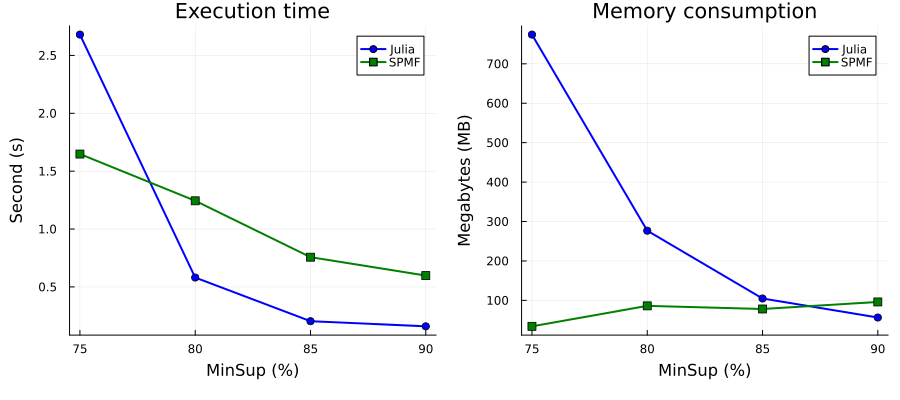

In [5]:
# ── Visualise Performance ─────────────────────────────────────────────────────
vis_performance(performance_result, logger)


### Evaluate Scalability

In [6]:
# ── Evaluation: Scalability (Time vs Data Size) ──────────────────────────────
scalability_result = eval_scalability(config, logger)


[process] Warming up JIT Compiler...

__________________________________________________
[phase]  SCALABILITY
__________________________________________________
[info] Minimum Support=90.0%
[process] Data Ratio = 25.0% (16890 giao dịch) ...
   [metric] Julia From Scratch (Proposed) Time: 0.532s | SPMF Built-in (Baseline) Time: 0.815s
[process] Data Ratio = 50.0% (33779 giao dịch) ...


Benchmarking...  50%|██████████████████                 |  ETA: 0:00:04

   [metric] Julia From Scratch (Proposed) Time: 0.132s | SPMF Built-in (Baseline) Time: 0.629s
[process] Data Ratio = 75.0% (50668 giao dịch) ...


Benchmarking...  75%|███████████████████████████        |  ETA: 0:00:02

   [metric] Julia From Scratch (Proposed) Time: 0.135s | SPMF Built-in (Baseline) Time: 0.563s
[process] Data Ratio = 100.0% (67557 giao dịch) ...


Benchmarking... 100%|███████████████████████████████████| Time: 0:00:06


   [metric] Julia From Scratch (Proposed) Time: 0.173s | SPMF Built-in (Baseline) Time: 0.571s
[success] Saved at ../results/connect4_scalability.csv


Row,DataRatio,NumTransactions,JuliaTime,SPMFTime
,Float64,Int64,Float64,Float64
1,0.25,16890,0.532445,0.815
2,0.5,33779,0.131537,0.629
3,0.75,50668,0.134753,0.563
4,1.0,67557,0.172964,0.571



__________________________________________________
[phase]  visualize
__________________________________________________


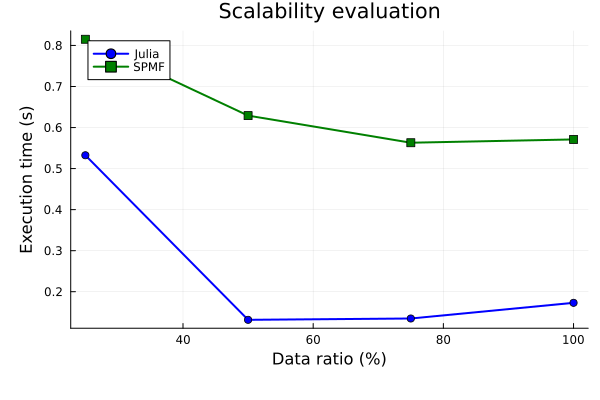

In [7]:
# ── Visualise Scalability ─────────────────────────────────────────────────────
vis_scalability(scalability_result, logger)


### Result

<!-- Bảng bên dưới hiển thị dữ liệu benchmark thô trực tiếp từ DataFrame. -->

In [8]:
println("__PERFORMANCE__")
display(performance_result)
println()
println("__SCALABILITY__")
display(scalability_result)


__PERFORMANCE__


Row,MinSup,Itemsets,JuliaTime,JuliaMemory,SPMFTime,SPMFMemory
,Float64,Int64,Float64,Float64,Float64,Float64
1,0.75,1585551,2.67996,774.13,1.648,34.187
2,0.8,533975,0.580878,276.758,1.244,86.1092
3,0.85,142127,0.20392,104.736,0.757,78.1342
4,0.9,27127,0.159607,56.52,0.598,96.0



__SCALABILITY__


Row,DataRatio,NumTransactions,JuliaTime,SPMFTime
,Float64,Int64,Float64,Float64
1,0.25,16890,0.532445,0.815
2,0.5,33779,0.131537,0.629
3,0.75,50668,0.134753,0.563
4,1.0,67557,0.172964,0.571
